В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay, root_mean_squared_error, mean_squared_error)

Area under ROC score: 0.88%
F1 Score: 0.6504


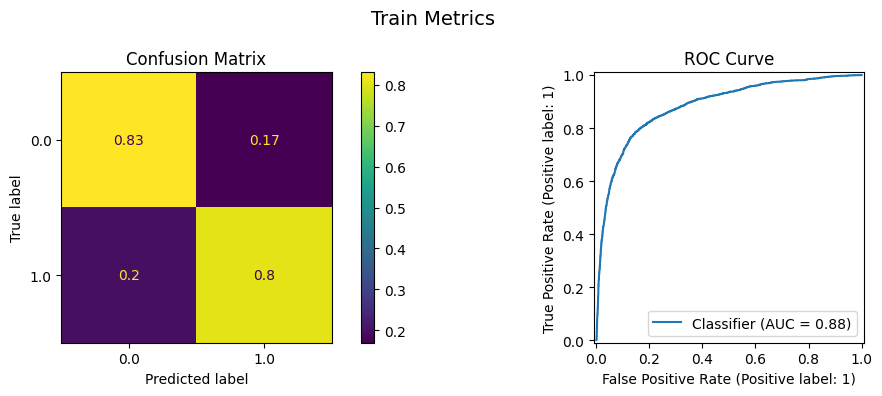

Area under ROC score: 0.88%
F1 Score: 0.6359


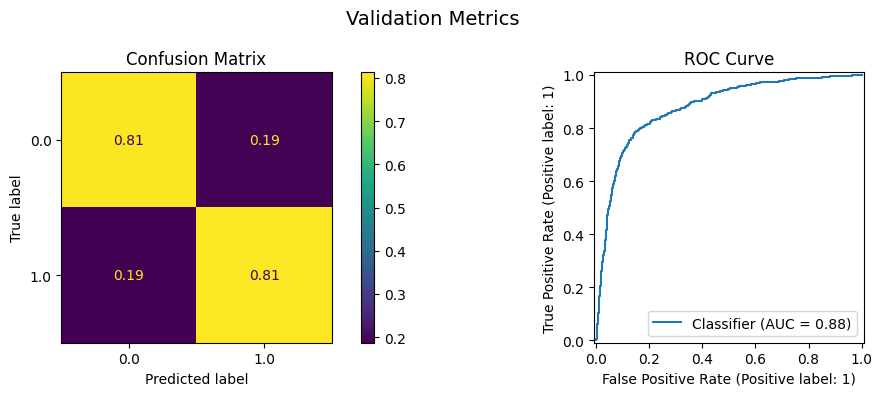

['bank_customers_pipeline.joblib']

In [2]:
raw_df = pd.read_csv('train.csv')

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['Exited'])

# Створюємо трен. і вал. набори
target_col = 'Exited'
input_cols = list(set(train_df.columns).difference([target_col, 'Surname']))
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

gender_col = ['Gender']
columns_to_encode = [col for col in categorical_cols if col not in gender_col]

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

gender_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Male', 'Female']]))  # Male=0, Female=1
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, columns_to_encode),
        ('gender', gender_transformer, gender_col)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, dataset_name=''):
    preds = model_pipeline.predict(inputs)
    probas = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probas)
    f1 = f1_score(targets, preds)
    print(f"Area under ROC score: {roc_auc:.2f}%")
    print(f"F1 Score: {f1:.4f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{dataset_name} Metrics', fontsize=14)

    ConfusionMatrixDisplay.from_predictions(targets, preds, ax=axes[0], normalize='true')
    axes[0].set_title('Confusion Matrix')

    RocCurveDisplay.from_predictions(targets, probas, ax=axes[1])
    axes[1].set_title('ROC Curve')
    
    plt.tight_layout()
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'bank_customers_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score: 0.93%
F1 Score: 0.7051


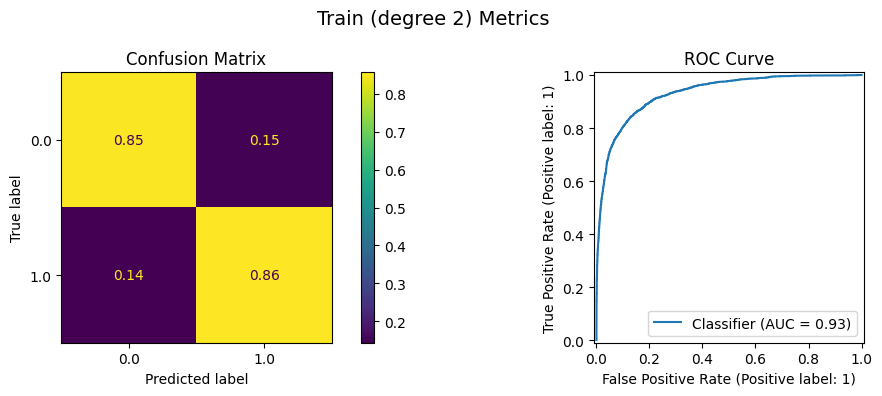

Area under ROC score: 0.93%
F1 Score: 0.6943


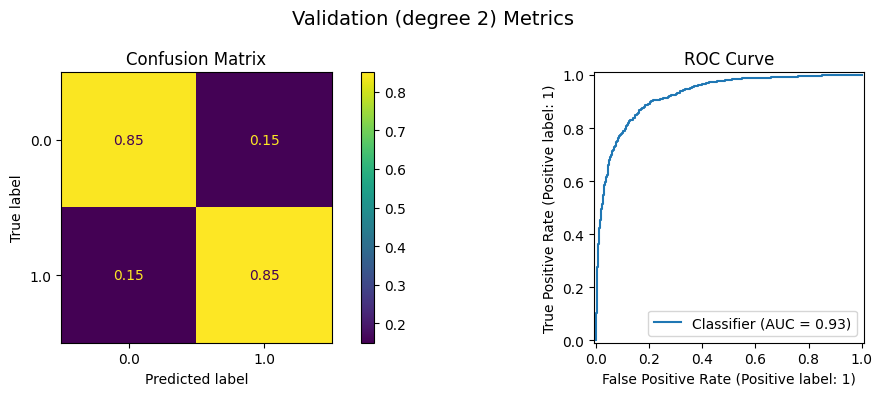

In [3]:
poly_numeric_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', poly_numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, columns_to_encode),
        ('gender', gender_transformer, gender_col)
    ])
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear'))
])

model_pipeline.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train (degree 2)')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation (degree 2)')

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score: 0.95%
F1 Score: 0.7341


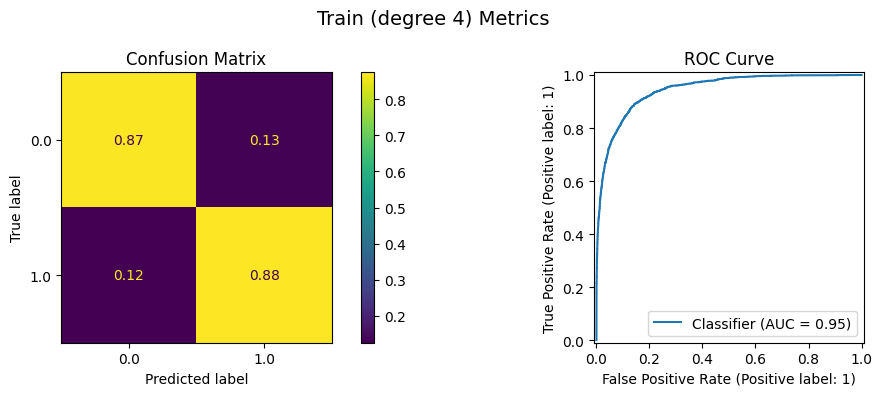

Area under ROC score: 0.93%
F1 Score: 0.7033


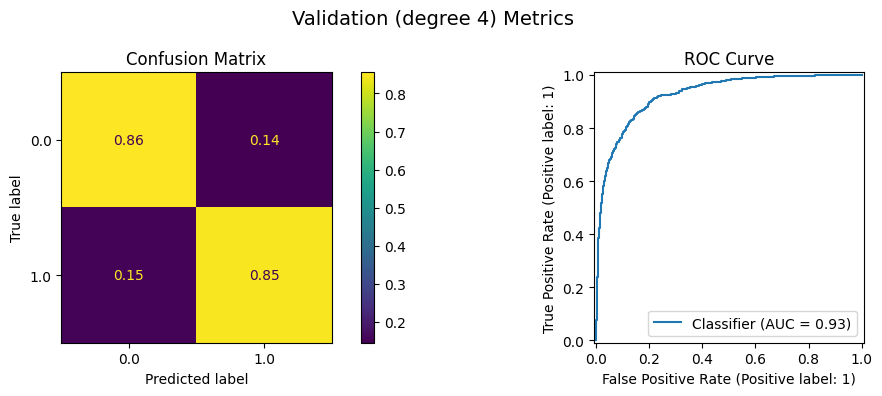

In [4]:
model_pipeline.set_params(preprocessor__num__poly__degree=4)
model_pipeline.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train (degree 4)')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation (degree 4)')

Метрики моделі покращилися на тренувальному наборі, але майже не змінились на валідаційному. Це означає, що скоріш ща все модель вже трохи перетренована. Пробувала також degree 3, теж схоже на overfit

In [5]:
# код для визначення найкращих параметрів та submission
params = {
    'preprocessor__num__poly__degree': [1, 2, 3],
    'classifier__C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(model_pipeline, params, scoring='roc_auc', cv=5)
grid.fit(train_inputs, train_targets)

print('Best params:', grid.best_params_)

Best params: {'classifier__C': 1, 'preprocessor__num__poly__degree': 3}


Area under ROC score: 0.93%
F1 Score: 0.7051


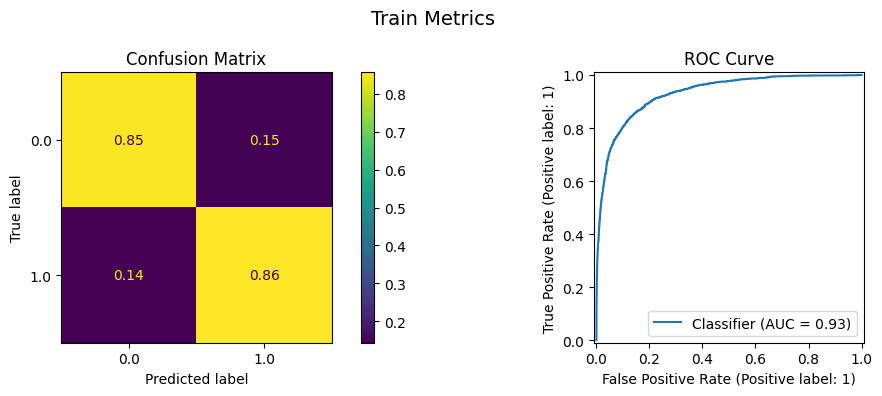

Area under ROC score: 0.93%
F1 Score: 0.6943


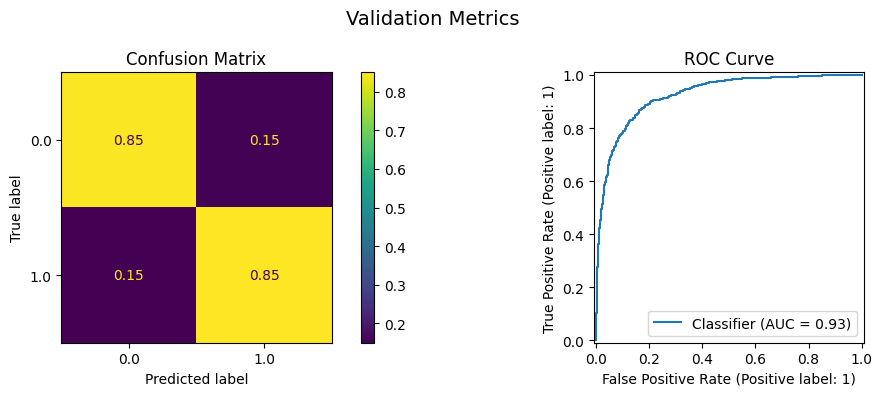

In [6]:
# код для submission
model_pipeline.set_params(preprocessor__num__poly__degree=2, classifier__C = 1)
model_pipeline.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

test_df = pd.read_csv('test.csv')
test_inputs = test_df[input_cols]

probas = model_pipeline.predict_proba(test_inputs)[:, 1]
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission['Exited'] = probas

sample_submission.to_csv('submission_log_reg_degree_2_c_1.csv', index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [7]:
reg_data_df = pd.read_csv('regression_data.csv')

train, validation = train_test_split(reg_data_df, test_size=0.2, random_state=53, shuffle=False)
reg_data_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [8]:
def lin_predict_and_plot(model, train_inputs, train_targets, val_inputs, val_targets):
    y_train_pred = model.predict(train_inputs)
    y_val_pred = model.predict(val_inputs)
    
    print(f'Train RMSE: {root_mean_squared_error(train_targets, y_train_pred)}')
    print(f'Test RMSE: {root_mean_squared_error(val_targets, y_val_pred)}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Train
    axes[0].scatter(train_targets, y_train_pred, alpha=0.5)
    axes[0].plot([train_targets.min(), train_targets.max()], 
                 [train_targets.min(), train_targets.max()], 'r--')  # ідеальна prediction line
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Train: Actual vs Predicted')
    
    # Validation
    axes[1].scatter(val_targets, y_val_pred, alpha=0.5)
    axes[1].plot([val_targets.min(), val_targets.max()], 
                 [val_targets.min(), val_targets.max()], 'r--')  # ідеальна prediction line
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Val: Actual vs Predicted')
    
    plt.tight_layout()
    plt.show()

Train target mean and std:  -5.88 42.33
Val target mean and std:  3.92 54.8
Train RMSE: 1.4904648490537113e-13
Test RMSE: 7.13731137268194


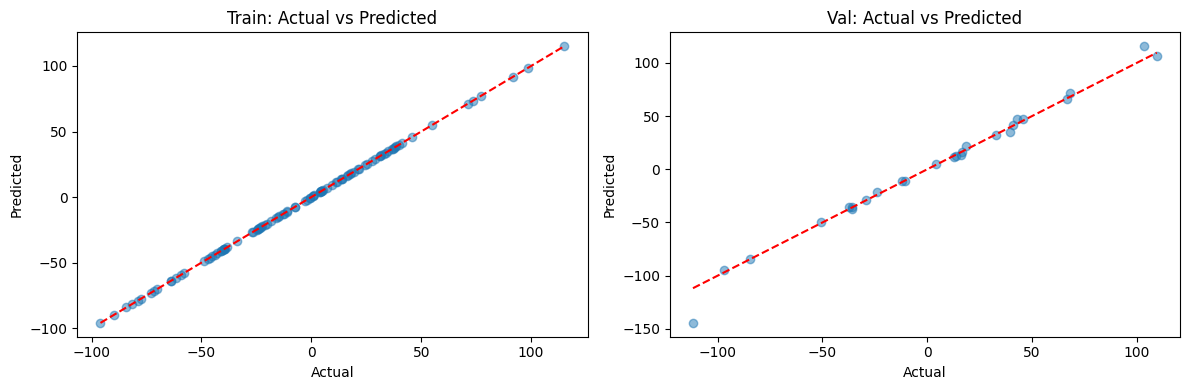

In [9]:
target = 'target'
inputs = list(set(train.columns).difference(target))

train_inputs, train_targets = train[inputs], train[target]
val_inputs, val_targets = validation[inputs], validation[target]

transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5)),
    ('scaler', MinMaxScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformer, inputs),
    ])

lin_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearRegression())
])

print('Train target mean and std: ', np.mean(train_targets).round(2), np.std(train_targets).round(2))
print('Val target mean and std: ', np.mean(val_targets).round(2), np.std(val_targets).round(2))

lin_model_pipeline.fit(train_inputs, train_targets)
lin_predict_and_plot(lin_model_pipeline, train_inputs, train_targets, val_inputs, val_targets)

Ми отримали overfit. Тестові дані передбачаються не дуже добре. Але з degree=3, 2 вдалось отримати хороший результат, а найкращий результат при degree=1, тому поліноміальні ознаки схоже тут не покращують модель (і це зрозуміло, з огляду на те, що в нас всього 128 рядків у датасеті - недостатньо даних навіть для створення ознак порядку degree 2)

Train RMSE: 6.721715930274475e-14
Test RMSE: 1.3759556810481978e-13


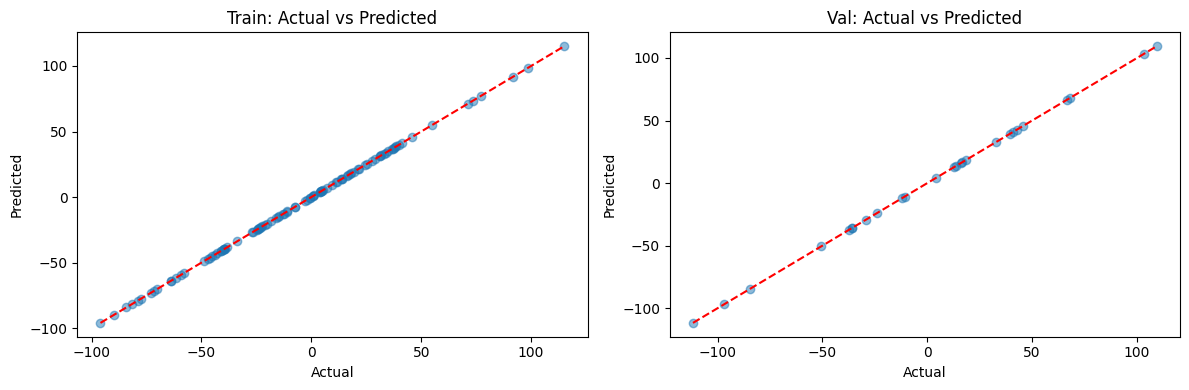

In [10]:
lin_model_pipeline.set_params(preprocessor__num__poly__degree=3)
lin_model_pipeline.fit(train_inputs, train_targets)

lin_predict_and_plot(lin_model_pipeline, train_inputs, train_targets, val_inputs, val_targets)

Train RMSE: 2.467070660885314e-14
Test RMSE: 2.8351165422467505e-14


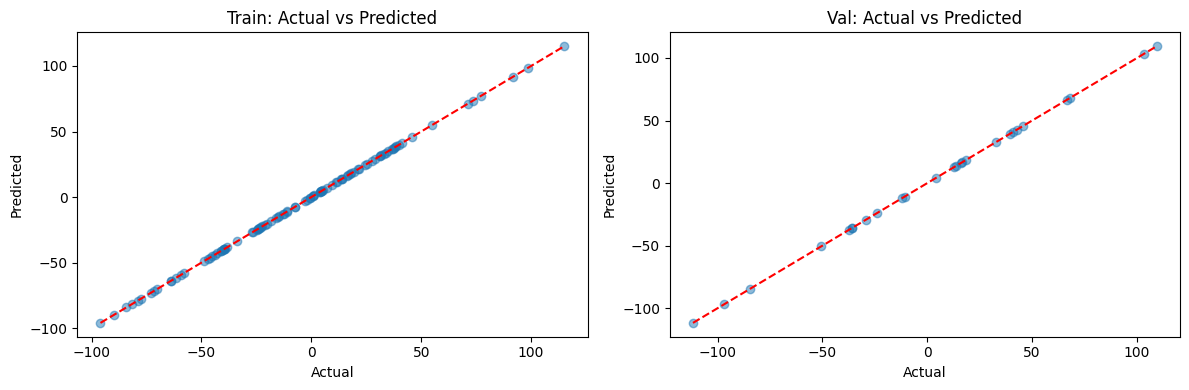

In [11]:
lin_model_pipeline.set_params(preprocessor__num__poly__degree=1)
lin_model_pipeline.fit(train_inputs, train_targets)

lin_predict_and_plot(lin_model_pipeline, train_inputs, train_targets, val_inputs, val_targets)

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

Model name: <class 'sklearn.linear_model._base.LinearRegression'>
Train RMSE: 6.395454556452155
Test RMSE: 2118806.2725466667


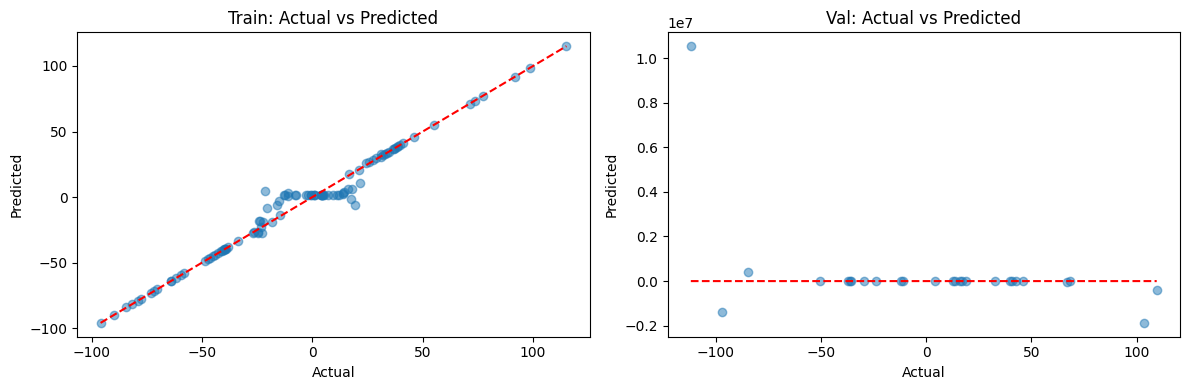

Model name: <class 'sklearn.linear_model._ridge.Ridge'>
Train RMSE: 22.953626334005712
Test RMSE: 5157.669827577078


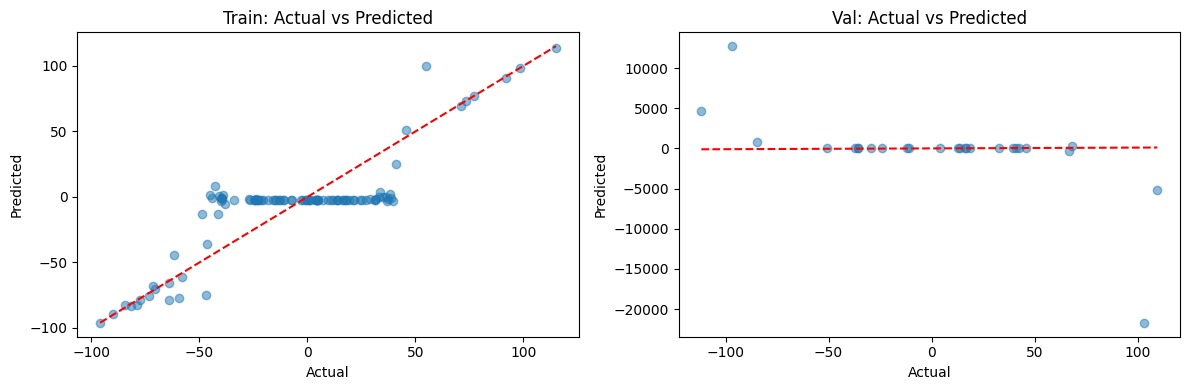

Model name: <class 'sklearn.linear_model._coordinate_descent.Lasso'>
Train RMSE: 0.10578478901506926
Test RMSE: 7.048601675654968


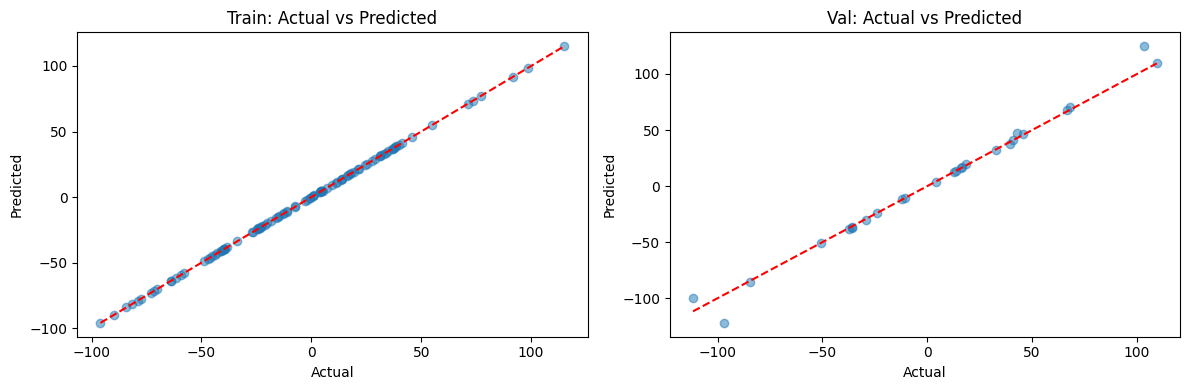

Model name: <class 'sklearn.linear_model._coordinate_descent.ElasticNet'>
Train RMSE: 0.10552621622039103
Test RMSE: 8.779462916217083


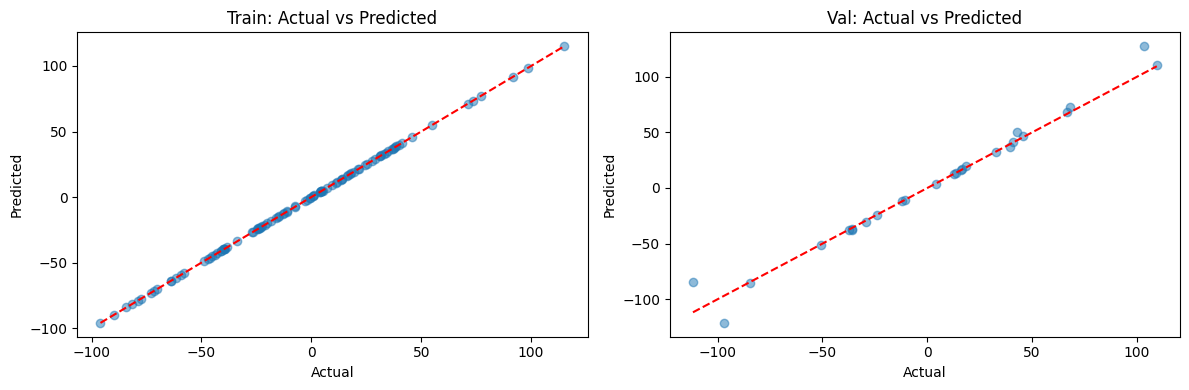

Model name: <class 'sklearn.linear_model._coordinate_descent.ElasticNet'>
Train RMSE: 0.05300507539517384
Test RMSE: 4.368917700298097


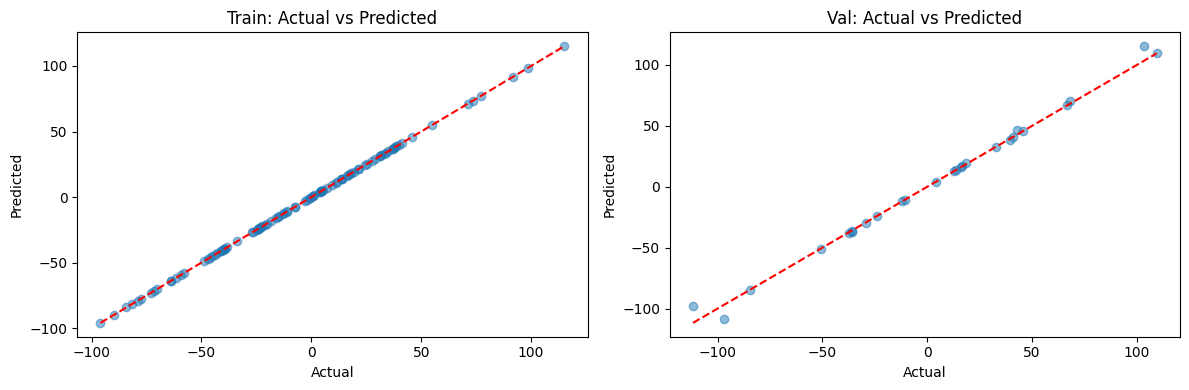

In [12]:
import warnings
warnings.filterwarnings("ignore")

models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
    ElasticNet(alpha=0.5)
]

poly_features = PolynomialFeatures(degree=10)
X_train_poly = poly_features.fit_transform(train_inputs)
X_val_poly = poly_features.transform(val_inputs)

for model in models:
    print('Model name:', type(model))
    model.fit(X_train_poly, train_targets)
    lin_predict_and_plot(model, X_train_poly, train_targets, X_val_poly, val_targets)

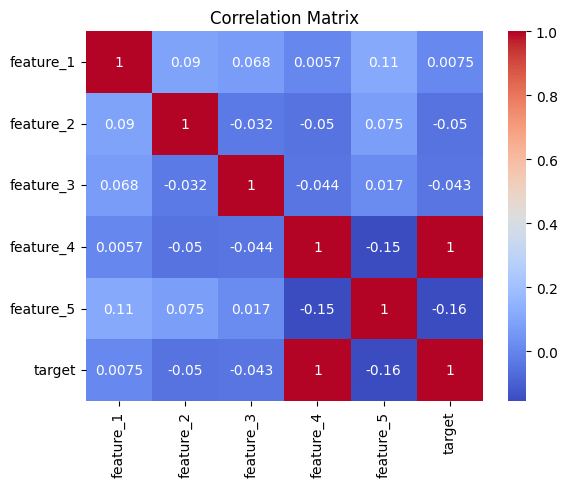

    feature_4     target
0    0.538910  28.938854
1   -0.147057  -7.664581
2   -1.260884 -63.845482
3    0.074095   4.076259
4    0.714000  34.879013
5    0.047399   0.672640
6   -1.594428 -78.934199
7    1.549934  77.093858
8    0.404051  18.058216
9    0.827183  41.134926
10  -1.220844 -61.642024
11   0.097078   3.730928
12  -0.334501 -15.024066
13  -1.550663 -77.534889
14  -1.415371 -73.196868
15   0.117327   7.093913
16  -0.234137 -10.864192
17   0.096996   4.289044
18   0.338496  16.469189
19   0.638592  31.166621


In [13]:
import seaborn as sns
sns.heatmap(reg_data_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

print(pd.DataFrame({
    'feature_4': reg_data_df['feature_4'],
    'target': reg_data_df['target']
}).head(20))

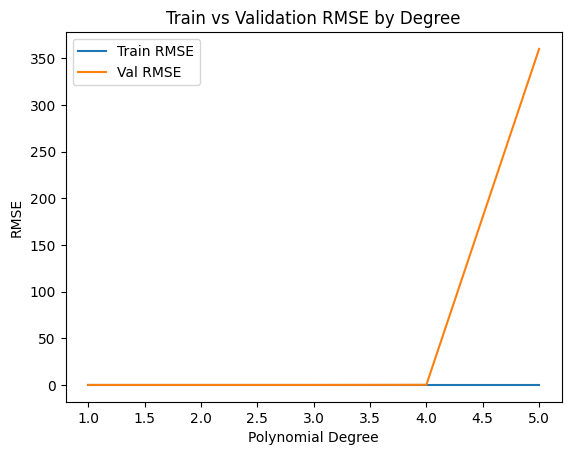

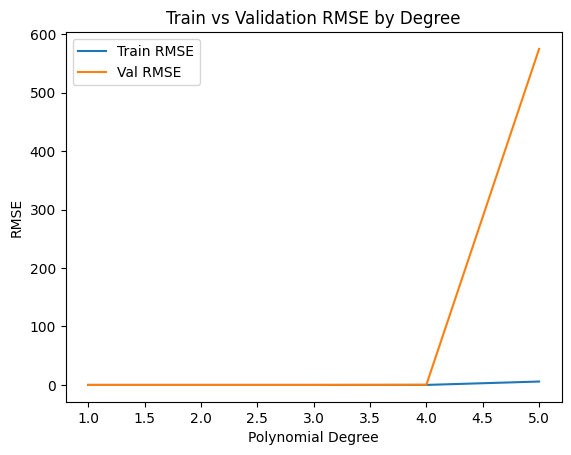

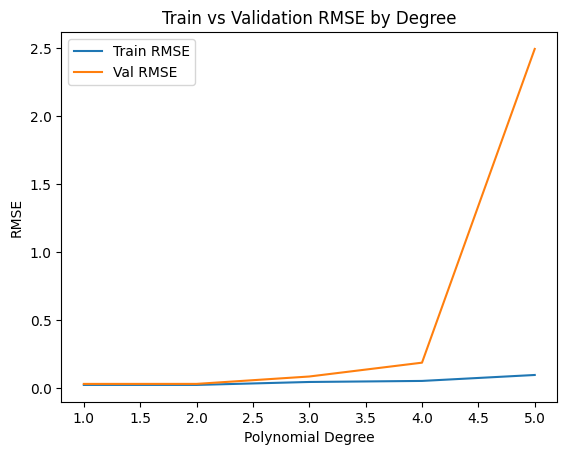

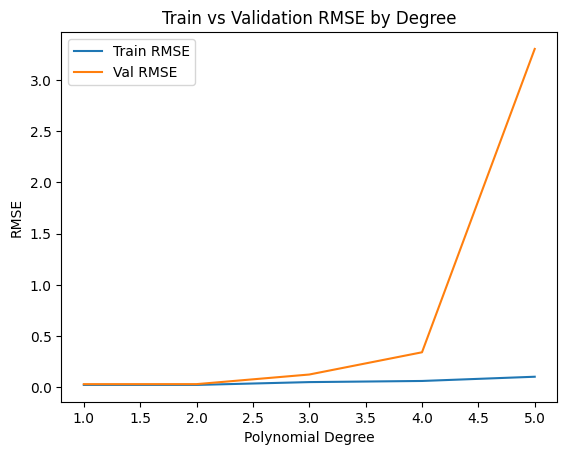

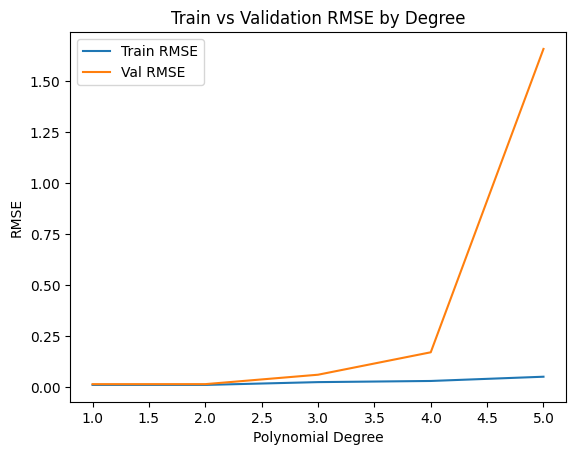

In [14]:
# графіки RMSE для моделі лінійної регресії залежно від degree
# в даному випадку не дуже помічні, але хочеться залишити цей код
for model in models:
    degrees = [1, 2, 3, 4, 5]
    train_scores = []
    val_scores = []
    for degree in degrees:
        poly_features = PolynomialFeatures(degree)
        train_inputs_poly = poly_features.fit_transform(train_inputs)
        val_inputs_poly = poly_features.transform(val_inputs)
        model.fit(train_inputs_poly, train_targets)
        train_scores.append(root_mean_squared_error(train_targets, model.predict(train_inputs_poly)))
        val_scores.append(root_mean_squared_error(val_targets, model.predict(val_inputs_poly)))
    
    plt.plot(degrees, train_scores, label='Train RMSE')
    plt.plot(degrees, val_scores, label='Val RMSE')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('RMSE')
    plt.legend()
    plt.title('Train vs Validation RMSE by Degree')
    plt.show()